<a href="https://colab.research.google.com/github/crowell97/transient_workshop/blob/main/CRESCENT_Transient_Workshop_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CRESCENT Transient Workshop

## Overview

This Jupyter notebook gives an overview of how to load the CRESCENT netCDF files of GNSS time series. There are 3 data providers: SOPAC, UNR, and PANGA. All data is provided with the same format, which allows algorithms to be quickly tested across different datasets.

Original User Guide written by Loic Bachelot. Modified by Brendan Crowell.



---

## 1. Environment Setup

Import all libraries needed throughout the notebook.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import pandas as pd
import calendar
import math
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.signal import detrend
from scipy.stats import kurtosis
from scipy.special import erf
from scipy.optimize import curve_fit, least_squares
from scipy.linalg import lstsq

# Plotting defaults for publication-quality figures
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 1.2,
    'legend.fontsize': 10,
})

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Loading the CRESCENT GNSS Dataset

The CRESCENT project provides three independently processed GPS time series datasets:

| Provider | Description |
|----------|-------------|
| **SOPAC** | Scripps Orbit and Permanent Array Center |
| **PANGA** | Pacific Northwest Geodetic Array |
| **UNR** | University of Nevada, Reno Nevada Geodetic Lab |

All three are provided in a unified netCDF format with identical variable names, allowing algorithm comparison across solutions. The UNR data is in the North American fixed reference frame whereas the SOPAC/PANGA solutions are in ITRF. The reference frame here matters when modeling the long term interseismic signals, but can be easily corrected with an Euler pole rotation. Also, double-check the units since it may be mm or meters; the interseismic velocities should be 10s of mm/yr.

In [2]:
import requests
from io import BytesIO

# ── Choose your data provider ──────────────────────────────────────────────
# Uncomment the URL for the dataset you want to use

# SOPAC data
#url = "https://zenodo.org/records/20518159/files/gnss_SOPAC_trend_2010_2025.nc?download=1" #Trended
url = "https://zenodo.org/records/19616474/files/gnss_SOPAC_2010_2025.nc?download=1" #Detrended

# PANGA data
#url = "https://zenodo.org/records/20518159/files/gnss_PANGA_trend_2010_2025.nc?download=1" #Trended
#url = "https://zenodo.org/records/19616474/files/gnss_PANGA_2010_2025.nc?download=1" #Detrended

# UNR data
#url = "https://zenodo.org/records/19616474/files/gnss_unr_2010_2025.nc?download=1" #Trended
#url = "https://zenodo.org/records/19616474/files/gnss_unr_2010_2025.nc?download=1" #Detrended

print(f"Downloading dataset...")
response = requests.get(url)
response.raise_for_status()

ds = xr.open_dataset(BytesIO(response.content), engine="h5netcdf")
print("Dataset loaded successfully!")
print(ds)

Dataset loaded successfully!
<xarray.Dataset> Size: 111MB
Dimensions:        (station: 340, time: 5840)
Coordinates:
  * station        (station) <U4 5kB 'albh' 'arli' 'asbu' ... 'yelm' 'yonc'
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
    lat            (station) float64 3kB ...
    lon            (station) float64 3kB ...
    elev_m         (station) float64 3kB ...
Data variables:
    dec_year       (station, time) float64 16MB ...
    east_m         (station, time) float64 16MB ...
    north_m        (station, time) float64 16MB ...
    up_m           (station, time) float64 16MB ...
    east_sigma_m   (station, time) float64 16MB ...
    north_sigma_m  (station, time) float64 16MB ...
    up_sigma_m     (station, time) float64 16MB ...


## 3. Dataset Inspection

Before analysis, it is critical to understand the structure and content of the dataset.

In [3]:
# ── Dataset dimensions and coordinates ───────────────────────────────────
print("=== Dataset Dimensions ===")
for dim, size in ds.dims.items():
    print(f"  {dim}: {size}")

print("\n=== Coordinates ===")
for coord in ds.coords:
    print(f"  {coord}: {ds[coord].dims}, dtype={ds[coord].dtype}")

print("\n=== Data Variables ===")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims}, dtype={ds[var].dtype}, units={ds[var].attrs.get('units','?')}")

=== Dataset Dimensions ===
  station: 340
  time: 5840

=== Coordinates ===
  time: ('time',), dtype=datetime64[ns]
  station: ('station',), dtype=<U4
  lat: ('station',), dtype=float64
  lon: ('station',), dtype=float64
  elev_m: ('station',), dtype=float64

=== Data Variables ===
  dec_year: ('station', 'time'), dtype=float64, units=?
  east_m: ('station', 'time'), dtype=float64, units=?
  north_m: ('station', 'time'), dtype=float64, units=?
  up_m: ('station', 'time'), dtype=float64, units=?
  east_sigma_m: ('station', 'time'), dtype=float64, units=?
  north_sigma_m: ('station', 'time'), dtype=float64, units=?
  up_sigma_m: ('station', 'time'), dtype=float64, units=?


In [4]:
# ── Station metadata ──────────────────────────────────────────────────────
station_lat  = ds.lat.values
station_lon  = ds.lon.values
station_elev = ds.elev_m.values
station_names = ds.station.values

print(f"Number of stations : {len(station_names)}")
print(f"Latitude range     : {np.nanmin(station_lat):.2f}° – {np.nanmax(station_lat):.2f}°N")
print(f"Longitude range    : {np.nanmin(station_lon):.2f}° – {np.nanmax(station_lon):.2f}°E")
print(f"Elevation range    : {np.nanmin(station_elev):.0f} – {np.nanmax(station_elev):.0f} m")
print(f"\nFirst 10 station names: {station_names[:10]}")

Number of stations : 340
Latitude range     : 39.53° – 50.64°N
Longitude range    : -128.13° – -121.05°E
Elevation range    : -22 – 3068 m

First 10 station names: ['albh' 'arli' 'asbu' 'ashl' 'bamf' 'bcov' 'beli' 'bend' 'bils' 'bly1']


## 4. Station Network Map

Visualizing the spatial distribution of the network helps identify regional coverage and select stations for detailed analysis. The CRESCENT dataset selected specific lat/lon boundaries and excluded sites with less than 5 years of data. More continuous stations exist if you check UNR's geodesy lab map (https://geodesy.unr.edu/NGLStationPages/gpsnetmap/GPSNetMap.html).

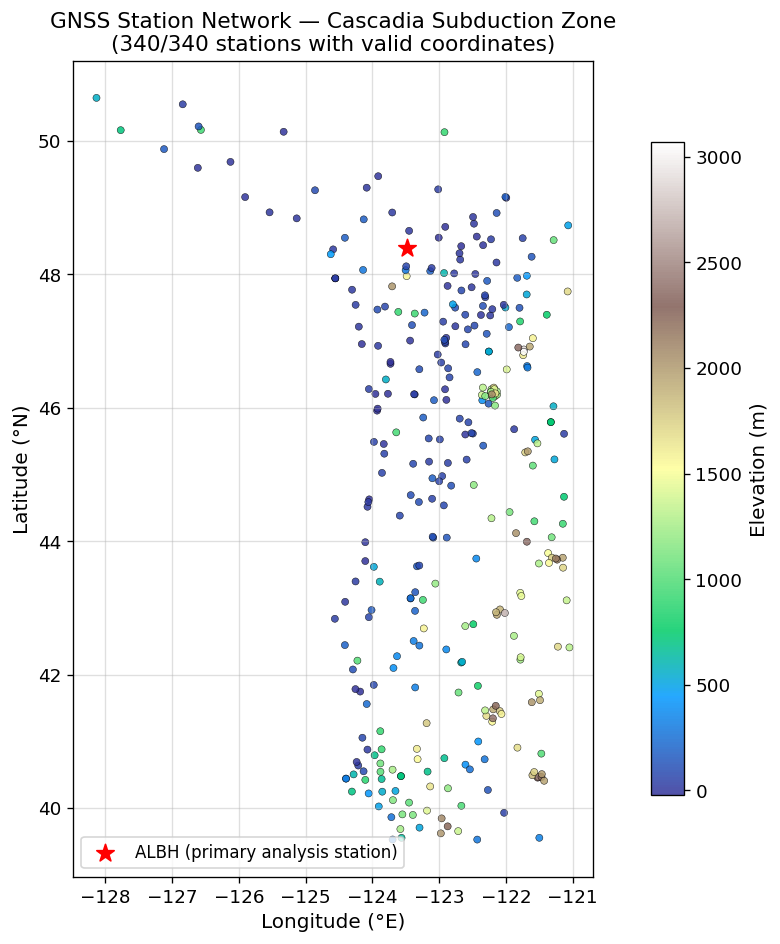

Map shows 340 stations with valid coordinates out of 340 total.


In [5]:
ds_plot = ds.where(ds.lon.notnull() & ds.lat.notnull(), drop=True)
n_total = ds.sizes["station"]
n_ok    = ds_plot.sizes["station"]

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(ds_plot.lon, ds_plot.lat, s=18, c=ds_plot.elev_m,
                cmap='terrain', alpha=0.85, edgecolors='k', linewidths=0.3)

# Highlight the primary analysis station (ALBH)
albh_lat = float(ds.sel(station="albh").lat)
albh_lon = float(ds.sel(station="albh").lon)
ax.scatter(albh_lon, albh_lat, s=120, c='red', marker='*',
           zorder=5, label='ALBH (primary analysis station)')

cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Elevation (m)")

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(f"GNSS Station Network — Cascadia Subduction Zone\n({n_ok}/{n_total} stations with valid coordinates)")
ax.legend(loc='lower left')
ax.grid(True, alpha=0.4)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()
print(f"Map shows {n_ok} stations with valid coordinates out of {n_total} total.")

## 5. Single Station Inspection: ALBH

Station ALBH (Albert Head, British Columbia) is one of the best-characterized continuous GPS sites in Cascadia, with a long record showing multiple well-documented ETS events. This is one of stations in the original ETS paper by Rogers and Dragert. We load all three displacement components (East, North, Up) and their uncertainties. The trend that will be shown in the SOPAC solutions are in the ITRF frame.

In [6]:
# ── Load ALBH ────────────────────────────────────────────────────────────
stat = ds.sel(station="albh")

df_albh = pd.DataFrame({
    'time'      : pd.to_datetime(stat.time.values),
    'dec_year'  : stat.dec_year.values,
    'east_mm'   : stat.east_m.values  * 1000,
    'north_mm'  : stat.north_m.values * 1000,
    'up_mm'     : stat.up_m.values    * 1000,
    'east_sig'  : stat.east_sigma_m.values  * 1000,
    'north_sig' : stat.north_sigma_m.values * 1000,
    'up_sig'    : stat.up_sigma_m.values    * 1000,
})

print(f"Station ALBH — {df_albh.shape[0]} daily observations")
print(f"Date range   : {df_albh.time.min().date()} → {df_albh.time.max().date()}")
print(f"\nData availability:")
for col in ['east_mm','north_mm','up_mm']:
    n_valid = df_albh[col].notna().sum()
    pct = 100*n_valid/len(df_albh)
    print(f"  {col:12s}: {n_valid:5d} valid ({pct:.1f}%)")

df_albh.head(10)

Station ALBH — 5840 daily observations
Date range   : 2010-01-01 → 2025-12-27

Data availability:
  east_mm     :  5829 valid (99.8%)
  north_mm    :  5829 valid (99.8%)
  up_mm       :  5829 valid (99.8%)


,time,dec_year,east_mm,north_mm,up_mm,east_sig,north_sig,up_sig
0,2010-01-01,2010.0014,2.50,2.16,2.49,2.12,1.53,4.90
1,2010-01-02,2010.0041,1.92,2.18,-0.61,1.85,1.41,4.38
2,2010-01-03,2010.0068,2.04,3.10,-6.71,1.72,1.41,4.25
3,2010-01-04,2010.0096,1.36,3.02,2.38,1.72,1.41,4.25
4,2010-01-05,2010.0123,1.29,3.24,2.78,1.99,1.41,4.51
5,2010-01-06,2010.0151,2.11,2.66,-0.72,1.85,1.41,4.64
6,2010-01-07,2010.0178,1.53,2.19,-4.32,1.99,1.41,4.64
7,2010-01-08,2010.0205,2.05,1.11,3.78,2.38,1.66,5.03
8,2010-01-09,2010.0233,2.17,0.53,4.58,1.99,1.53,4.64
9,2010-01-10,2010.0260,0.89,1.25,-1.43,2.25,1.53,4.90


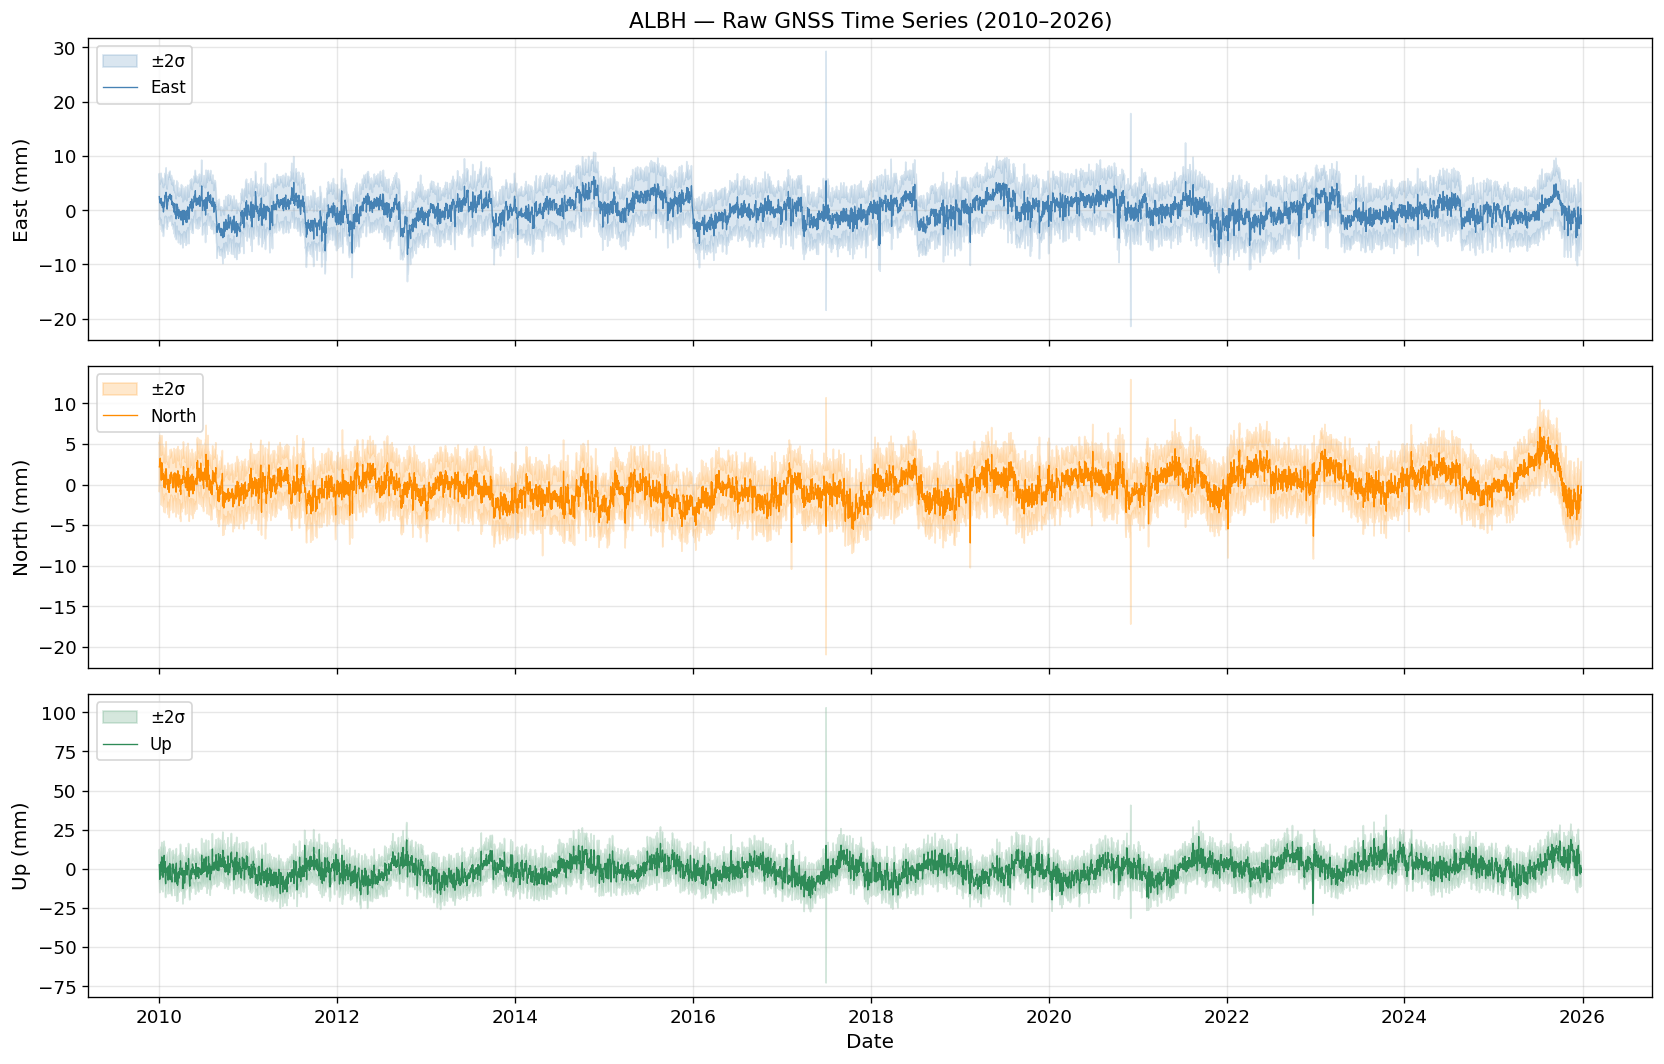

In [7]:
# ── Full record 3-component plot ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
components = [('east_mm', 'East',  'steelblue'),
              ('north_mm', 'North', 'darkorange'),
              ('up_mm',    'Up',    'seagreen')]

for ax, (col, label, color) in zip(axes, components):
    sig_col = col.replace('_mm','_sig')
    ax.fill_between(df_albh.time,
                    df_albh[col] - 2*df_albh[sig_col],
                    df_albh[col] + 2*df_albh[sig_col],
                    alpha=0.2, color=color, label='±2σ')
    ax.plot(df_albh.time, df_albh[col], color=color, lw=0.8, label=label)
    ax.set_ylabel(f"{label} (mm)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

axes[0].set_title("ALBH — Raw GNSS Time Series (2010–2026)")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 9. Transient Detection: RSI + Kurtosis Method

The Crowell et al. (2016) method detects slow slip events by:

1. Computing the **Relative Strength Index (RSI)** — adapted from financial time series analysis — on the detrended displacement. RSI quantifies the momentum of displacement changes.
2. Applying a **central moving average (CMA)** to the RSI.
3. Evaluating the **kurtosis** of expanding subsets of the CMA, comparing to an empirical null distribution.
4. The resulting probability time series spikes when the displacement pattern departs from background noise characteristics.

The approach is powerful because it is *model-free* — it does not assume a shape for the transient.

In [8]:
def kurtsolver(tseries):
    # Compute per-sample probability of transient based on kurtosis CDF.
    # Crowell et al. (2016) implementation.
    tseries = np.asarray(tseries)
    n = len(tseries)

    a1 = np.where(tseries >= 50)[0]
    a2 = np.where(tseries <= 50)[0]

    diff_pos = np.abs(tseries[a1] - 50);  ind_pos = np.argsort(diff_pos);  sort_pos = diff_pos[ind_pos]
    diff_neg = np.abs(tseries[a2] - 50);  ind_neg = np.argsort(diff_neg);  sort_neg = diff_neg[ind_neg]

    kurt_pos = np.zeros(len(sort_pos))
    kurt_neg = np.zeros(len(sort_neg))

    if len(sort_pos) > 200:
        for i in range(199, len(sort_pos)):
            kurt_pos[i] = kurtosis(sort_pos[:i+1], fisher=False)
    if len(sort_neg) > 200:
        for i in range(199, len(sort_neg)):
            kurt_neg[i] = kurtosis(sort_neg[:i+1], fisher=False)

    mu = 3.219936;  sigma = 0.119518

    cdf_neg = 0.5 * (1 + erf((kurt_neg - mu) / (sigma * np.sqrt(2))))
    cdf_pos = 0.5 * (1 + erf((kurt_pos - mu) / (sigma * np.sqrt(2))))

    prob = np.zeros(n)
    for i in range(len(a1)):
        prob[a1[ind_pos[i]]] = cdf_pos[i]
    for i in range(len(a2)):
        prob[a2[ind_neg[i]]] = -cdf_neg[i]

    return prob


def centralmovavg(tseries, n):
    # Central moving average with 'same' padding.
    kernel = np.ones(n) / n
    return np.convolve(tseries, kernel, mode='same')


def compute_rsi(prices, window=21):
    # Wilder's Relative Strength Index adapted for GPS displacement.
    # Returns array same length as prices, NaN for first 'window' samples.
    deltas = np.diff(prices)
    gains  = np.where(deltas > 0, deltas, 0.0)
    losses = np.where(deltas < 0, -deltas, 0.0)

    rsi = np.full_like(prices, np.nan, dtype=float)

    avg_gain = np.nanmean(gains[:window])
    avg_loss = np.nanmean(losses[:window])

    rsi[window] = 100 if avg_loss == 0 else 100 - 100 / (1 + avg_gain / avg_loss)

    for i in range(window + 1, len(prices)):
        avg_gain = (avg_gain * (window - 1) + gains[i-1]) / window
        avg_loss = (avg_loss * (window - 1) + losses[i-1]) / window
        rsi[i] = 100 if avg_loss == 0 else 100 - 100 / (1 + avg_gain / avg_loss)

    return rsi


print("RSI + Kurtosis detection functions defined.")

RSI + Kurtosis detection functions defined.


In [9]:
# ── Apply transient detection to the RAW (uncorrected) time series ───────
# NOTE: this uses the raw East displacement straight from the netCDF file
# (df_albh['east_mm']), NOT a detrended/model-corrected residual.
east_raw = df_albh['east_mm'].values.copy()

# Fill NaN with linear interpolation before RSI (RSI cannot handle NaN gaps)
valid = ~np.isnan(east_raw)
if np.sum(valid) > 0:
    east_interp = np.interp(np.arange(len(east_raw)),
                             np.where(valid)[0], east_raw[valid])
else:
    east_interp = east_raw.copy()

# RSI → CMA → Kurtosis probability
ersi  = compute_rsi(east_interp, window=21)
# Replace NaN in RSI with 50 (neutral) before CMA
ersi_clean = np.where(np.isnan(ersi), 50.0, ersi)
ecma  = centralmovavg(ersi_clean - np.nanmean(ersi_clean) + 50, 21)
eprob = kurtsolver(ecma)

# Store in dataframe
df_albh['east_rsi']  = ersi
df_albh['east_cma']  = ecma
df_albh['east_prob'] = eprob
df_albh['east_raw']  = east_raw

print(f"RSI mean    : {np.nanmean(ersi):.2f} (expect ~50 for random noise)")
print(f"CMA range   : [{ecma.min():.2f}, {ecma.max():.2f}]")
print(f"Prob range  : [{eprob.min():.4f}, {eprob.max():.4f}]")
print(f"Events (prob > 0.90): {(eprob > 0.90).sum()} days")
print(f"Events (prob < -0.90): {(eprob < -0.90).sum()} days")

RSI mean    : 49.98 (expect ~50 for random noise)
CMA range   : [26.20, 55.37]
Prob range  : [-1.0000, 1.0000]
Events (prob > 0.90): 14 days
Events (prob < -0.90): 284 days


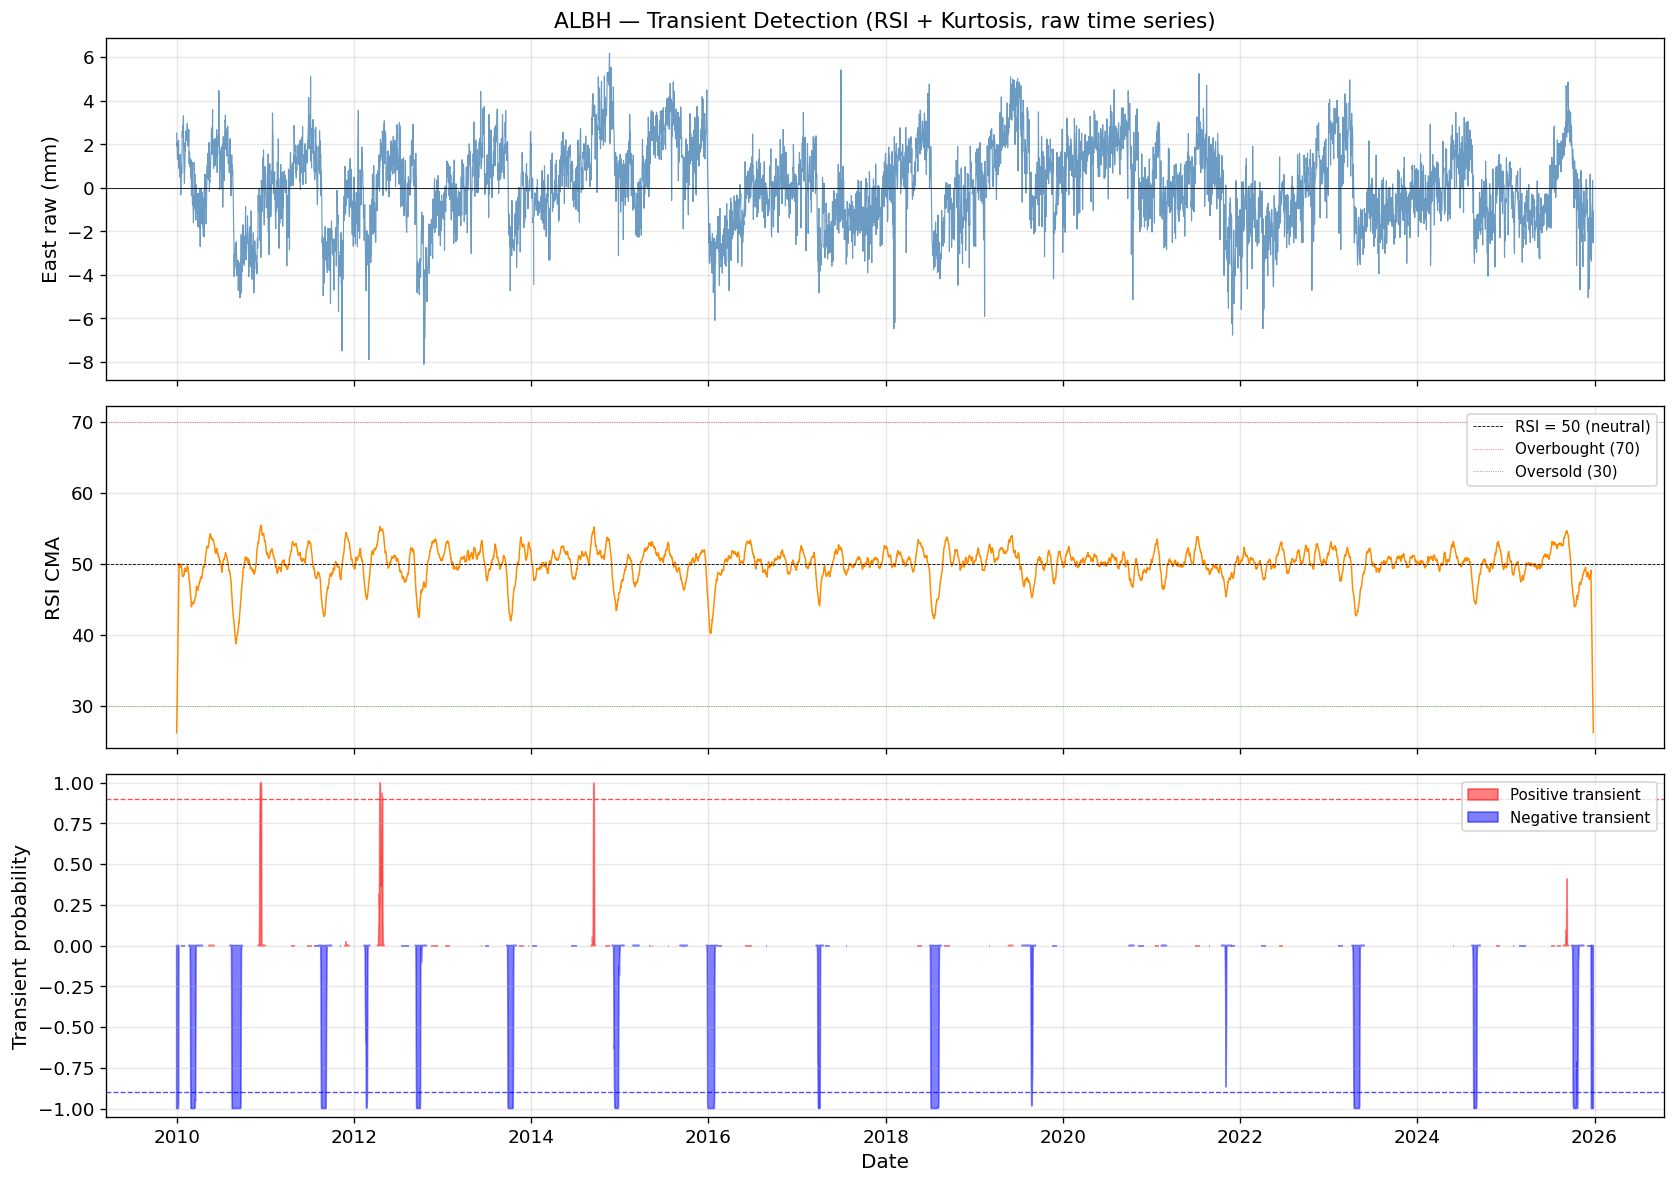

In [10]:
# ── Full probability time series plot ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# A. East raw displacement (straight from netCDF, no model correction)
axes[0].plot(df_albh.time, df_albh.east_raw, 'steelblue', lw=0.7, alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_ylabel("East raw (mm)")
axes[0].set_title("ALBH — Transient Detection (RSI + Kurtosis, raw time series)")
axes[0].grid(True, alpha=0.3)

# B. RSI CMA
axes[1].plot(df_albh.time, df_albh.east_cma, 'darkorange', lw=0.9)
axes[1].axhline(50, color='k', lw=0.5, ls='--', label='RSI = 50 (neutral)')
axes[1].axhline(70, color='red', lw=0.5, ls=':', alpha=0.7, label='Overbought (70)')
axes[1].axhline(30, color='green', lw=0.5, ls=':', alpha=0.7, label='Oversold (30)')
axes[1].set_ylabel("RSI CMA")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# C. Kurtosis probability
axes[2].fill_between(df_albh.time, 0, df_albh.east_prob,
                     where=df_albh.east_prob > 0, color='red', alpha=0.5, label='Positive transient')
axes[2].fill_between(df_albh.time, 0, df_albh.east_prob,
                     where=df_albh.east_prob < 0, color='blue', alpha=0.5, label='Negative transient')
axes[2].axhline(0.9, color='red', lw=0.8, ls='--', alpha=0.7)
axes[2].axhline(-0.9, color='blue', lw=0.8, ls='--', alpha=0.7)
axes[2].set_ylabel("Transient probability")
axes[2].set_xlabel("Date")
axes[2].set_ylim(-1.05, 1.05)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Identify Slow Slip Events

From the probability time series, we extract the time periods of significant transient activity. These correspond to ETS events in Cascadia, which recur approximately every 12–14 months near ALBH.

In [11]:
# ── Identify transient windows ────────────────────────────────────────────
PROB_THRESHOLD = 0.85       # probability threshold for detection
MIN_DURATION   = 5        # minimum consecutive days above threshold

prob = df_albh.east_prob.values
time = df_albh.time.values

# Label positive transient days
pos_flag = np.absolute(prob) > PROB_THRESHOLD
# Cluster into events
from itertools import groupby

events = []
for key, group in groupby(enumerate(pos_flag), key=lambda x: x[1]):
    if key:
        indices = [i for i, _ in group]
        if len(indices) >= MIN_DURATION:
            t_start = pd.Timestamp(time[indices[0]])
            t_end   = pd.Timestamp(time[indices[-1]])
            peak_prob = prob[indices].max()
            peak_date = pd.Timestamp(time[indices[np.argmax(prob[indices])]])
            events.append({
                'start'    : t_start,
                'end'      : t_end,
                'peak_date': peak_date,
                'duration' : len(indices),
                'max_prob' : peak_prob,
            })

print(f"Detected {len(events)} positive transient events (prob > {PROB_THRESHOLD}, ≥{MIN_DURATION} days):")
print()
print(f"{'#':<4} {'Start':<12} {'End':<12} {'Peak':<12} {'Dur(days)':<12} {'Max prob':<10}")
print("-" * 60)
for i, ev in enumerate(events):
    print(f"{i:<4} {str(ev['start'].date()):<12} {str(ev['end'].date()):<12} "
          f"{str(ev['peak_date'].date()):<12} {ev['duration']:<12} {ev['max_prob']:.4f}")

Detected 16 positive transient events (prob > 0.85, ≥5 days):

#    Start        End          Peak         Dur(days)    Max prob  
------------------------------------------------------------
0    2010-01-01   2010-01-09   2010-01-09   9            -0.9703
1    2010-03-01   2010-03-20   2010-03-19   20           -0.9478
2    2010-08-17   2010-09-23   2010-08-17   38           -0.9071
3    2010-12-11   2010-12-17   2010-12-13   7            1.0000
4    2011-08-21   2011-09-09   2011-09-09   20           -0.9871
5    2012-02-22   2012-02-26   2012-02-26   5            -0.9367
6    2012-09-16   2012-10-02   2012-10-02   17           -0.9425
7    2013-09-28   2013-10-19   2013-09-28   22           -0.9830
8    2014-12-11   2014-12-27   2014-12-11   17           -0.9153
9    2015-12-30   2016-01-27   2016-01-27   29           -0.9231
10   2017-03-30   2017-04-06   2017-03-30   8            -0.9956
11   2018-07-07   2018-08-09   2018-08-09   34           -0.8889
12   2023-04-16   2023-05-09 

## 10b. Network-Wide Transient Detection

We now run the same RSI + Kurtosis pipeline (Section 9), on the **raw East displacement**, independently for **every station** in the dataset. This lets us see whether transients detected at ALBH are shared across the network (consistent with a regional slow slip event) or are isolated/local (more likely noise, local site effects, or non-tectonic signals).

For each station we:
1. Interpolate small data gaps
2. Compute RSI → central moving average → kurtosis-based transient probability, exactly as for ALBH
3. Cluster consecutive high-probability days into discrete events
4. Record each event's peak date, duration, and station latitude/longitude

This can take a while to run since the kurtosis solver is applied per-station across the full record.

In [12]:
# ══════════════════════════════════════════════════════════════════
# NETWORK-WIDE TRANSIENT DETECTION (RSI + Kurtosis) — ALL STATIONS
# Uses the RAW East displacement (east_m), no model correction/detrending
# ══════════════════════════════════════════════════════════════════
from itertools import groupby

STATION_PROB_THRESHOLD = 0.75   # transient probability threshold
STATION_MIN_DURATION   = 2      # minimum consecutive days above threshold
MIN_VALID_OBS          = 200    # skip stations with too little data

all_station_names = ds.station.values
station_events = []   # one row per detected event, across all stations

n_skipped = 0
for sname in all_station_names:
    stat_i = ds.sel(station=sname)
    lat_i  = float(stat_i.lat)
    lon_i  = float(stat_i.lon)
    if np.isnan(lat_i) or np.isnan(lon_i):
        n_skipped += 1
        continue

    east_i = stat_i.east_m.values * 1000   # raw East displacement, mm
    time_i = pd.to_datetime(stat_i.time.values)

    valid_i = ~np.isnan(east_i)
    if valid_i.sum() < MIN_VALID_OBS:
        n_skipped += 1
        continue

    east_interp_i = np.interp(np.arange(len(east_i)),
                               np.where(valid_i)[0], east_i[valid_i])

    try:
        rsi_i       = compute_rsi(east_interp_i, window=21)
        rsi_clean_i = np.where(np.isnan(rsi_i), 50.0, rsi_i)
        cma_i       = centralmovavg(rsi_clean_i - np.nanmean(rsi_clean_i) + 50, 21)
        prob_i      = kurtsolver(cma_i)
    except Exception as e:
        print(f"  Skipping {str(sname)}: {e}")
        n_skipped += 1
        continue

    pos_flag_i = np.abs(prob_i) > STATION_PROB_THRESHOLD
    for key, group in groupby(enumerate(pos_flag_i), key=lambda x: x[1]):
        if not key:
            continue
        indices = [idx for idx, _ in group]
        if len(indices) < STATION_MIN_DURATION:
            continue
        peak_idx = indices[int(np.argmax(np.abs(prob_i[indices])))]
        station_events.append({
            'station'  : str(sname),
            'lat'      : lat_i,
            'lon'      : lon_i,
            'start'    : time_i[indices[0]],
            'end'      : time_i[indices[-1]],
            'peak_date': time_i[peak_idx],
            'duration' : len(indices),
            'max_prob' : prob_i[peak_idx],
        })

df_events = pd.DataFrame(station_events)
print(f"Processed {len(all_station_names)} stations ({n_skipped} skipped: no coords or insufficient data)")
print(f"Detected {len(df_events)} transient events across the network "
      f"from {df_events['station'].nunique() if len(df_events) else 0} stations")
df_events.sort_values('peak_date').head(10)

Processed 340 stations (0 skipped: no coords or insufficient data)
Detected 8526 transient events across the network from 340 stations


,station,lat,lon,start,end,peak_date,duration,max_prob
0,albh,48.389781,-123.487470,2010-01-01,2010-01-09,2010-01-01,9,-1.0
4911,p441,48.915979,-122.139642,2010-01-01,2010-01-09,2010-01-01,9,-1.0
4907,p440,48.856193,-122.493341,2010-01-01,2010-01-07,2010-01-01,7,-1.0
748,coup,48.217311,-122.685605,2010-01-01,2010-01-09,2010-01-01,9,-1.0
4892,p439,48.708193,-122.909303,2010-01-01,2010-01-08,2010-01-01,8,-1.0
774,cpco,43.722101,-121.233156,2010-01-01,2010-01-08,2010-01-01,8,-1.0
7366,tdls,45.607711,-121.129507,2010-01-01,2010-01-08,2010-01-01,8,-1.0
4765,p438,48.419148,-122.670263,2010-01-01,2010-01-08,2010-01-01,8,-1.0
4753,p437,48.001809,-122.459158,2010-01-01,2010-01-08,2010-01-01,8,-1.0
223,bils,47.539344,-124.252527,2010-01-01,2010-01-07,2010-01-01,7,-1.0


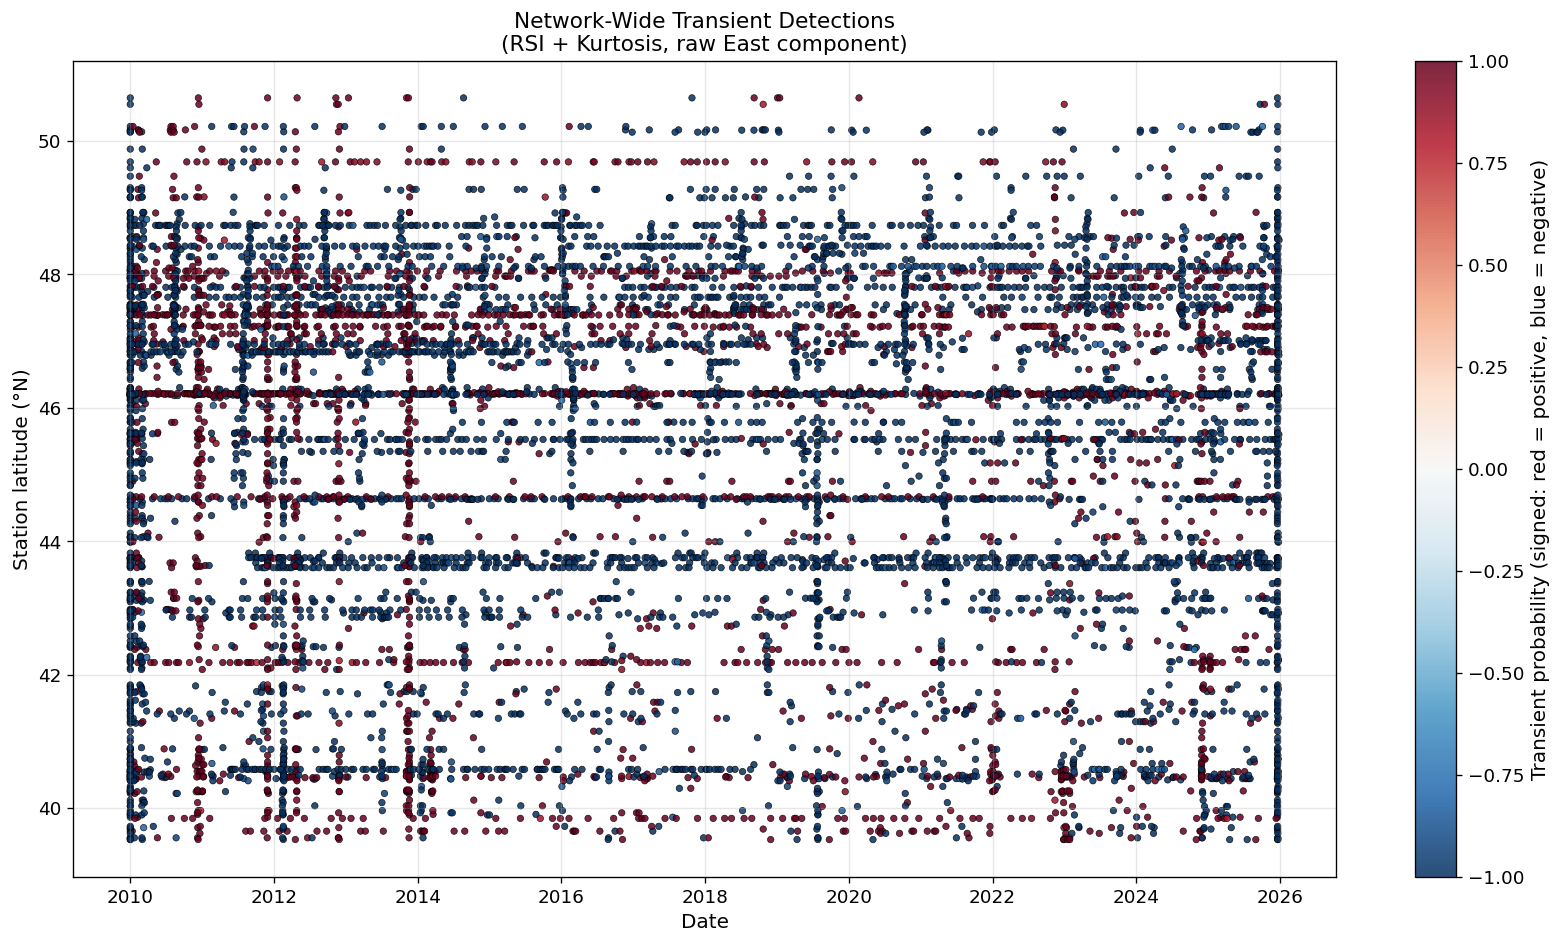

Plotted 8526 transient detections from 340 stations


In [13]:
# ── Plot: Station Latitude vs. Time of Detected Transients ───────────────
fig, ax = plt.subplots(figsize=(14, 8))

sc = ax.scatter(df_events['peak_date'], df_events['lat'],
                 s=15,
                 c=df_events['max_prob'], cmap='RdBu_r', vmin=-1, vmax=1,
                 edgecolors='k', linewidths=0.4, alpha=0.85)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Transient probability (signed: red = positive, blue = negative)")

ax.set_xlabel("Date")
ax.set_ylabel("Station latitude (°N)")
ax.set_title("Network-Wide Transient Detections\n(RSI + Kurtosis, raw East component)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plotted {len(df_events)} transient detections "
      f"from {df_events['station'].nunique() if len(df_events) else 0} stations")

In [14]:
# ── Save network-wide transient catalog to disk ───────────────────────────
events_filename = "gnss_network_transient_detections.csv"
df_events.sort_values(['peak_date', 'lat']).to_csv(events_filename, index=False)
print(f"Wrote {len(df_events)} events to '{events_filename}'")
df_events.sort_values(['peak_date', 'lat']).head(10)

Wrote 8526 events to 'gnss_network_transient_detections.csv'


,station,lat,lon,start,end,peak_date,duration,max_prob
3478,p336,39.528080,-122.430484,2010-01-01,2010-01-08,2010-01-01,8,-1.0
3204,p312,39.529178,-123.698374,2010-01-01,2010-01-09,2010-01-01,9,-1.0
3216,p313,39.554288,-123.564545,2010-01-01,2010-01-09,2010-01-01,9,-1.0
2749,orvb,39.554627,-121.500291,2010-01-01,2010-01-08,2010-01-01,8,-1.0
3447,p333,39.621381,-122.975754,2010-01-01,2010-01-08,2010-01-01,8,-1.0
1208,gasb,39.654707,-122.715931,2010-01-01,2010-01-08,2010-01-01,8,-1.0
3234,p314,39.685663,-123.581847,2010-01-01,2010-01-09,2010-01-01,9,-1.0
3277,p319,39.707097,-123.295078,2010-01-01,2010-01-09,2010-01-01,9,-1.0
3460,p335,39.726190,-122.873637,2010-01-01,2010-01-09,2010-01-01,9,-1.0
3242,p315,39.863583,-123.716896,2010-01-01,2010-01-08,2010-01-01,8,-1.0


## 11. Extract and Analyze a Single Slow Slip Event

We now zoom into **one well-defined slow slip event** for detailed analysis. The late-2015 Cascadia ETS event (December 2015 to January 2016) is one of the strongest in the instrumental record near Victoria, BC and is clearly visible at ALBH.

We will:
1. Window the data around the event
2. Fit pre- and post-event linear trends
3. Estimate the coseismic-style offset
4. Characterize the temporal evolution (onset ramp)

In [15]:
# ── Select event for detailed analysis ────────────────────────────────────
# Change these dates to examine different events
SSE_TSTART = '2015-12-28'
SSE_TEND   = '2016-01-27'

# Pre-event reference window (60 days before start)
PRE_DAYS  = 60
POST_DAYS = 60

t_event_start = pd.Timestamp(SSE_TSTART)
t_event_end   = pd.Timestamp(SSE_TEND)
t_pre_start   = t_event_start - pd.Timedelta(days=PRE_DAYS)
t_post_end    = t_event_end   + pd.Timedelta(days=POST_DAYS)

# Subset the data
mask_event = (df_albh.time >= t_event_start) & (df_albh.time <= t_event_end)
mask_window = (df_albh.time >= t_pre_start)  & (df_albh.time <= t_post_end)

df_sse    = df_albh[mask_event].copy()
df_window = df_albh[mask_window].copy()

print(f"Event window   : {SSE_TSTART} → {SSE_TEND} ({mask_event.sum()} days)")
print(f"Analysis window: {t_pre_start.date()} → {t_post_end.date()} ({mask_window.sum()} days)")
print(f"\nPeak raw East displacement during event : {df_sse.east_raw.max():.2f} mm")
print(f"Peak raw North displacement during event: {df_sse.north_mm.max():.2f} mm")

Event window   : 2015-12-28 → 2016-01-27 (31 days)
Analysis window: 2015-10-29 → 2016-03-27 (151 days)

Peak raw East displacement during event : 2.04 mm
Peak raw North displacement during event: -1.56 mm


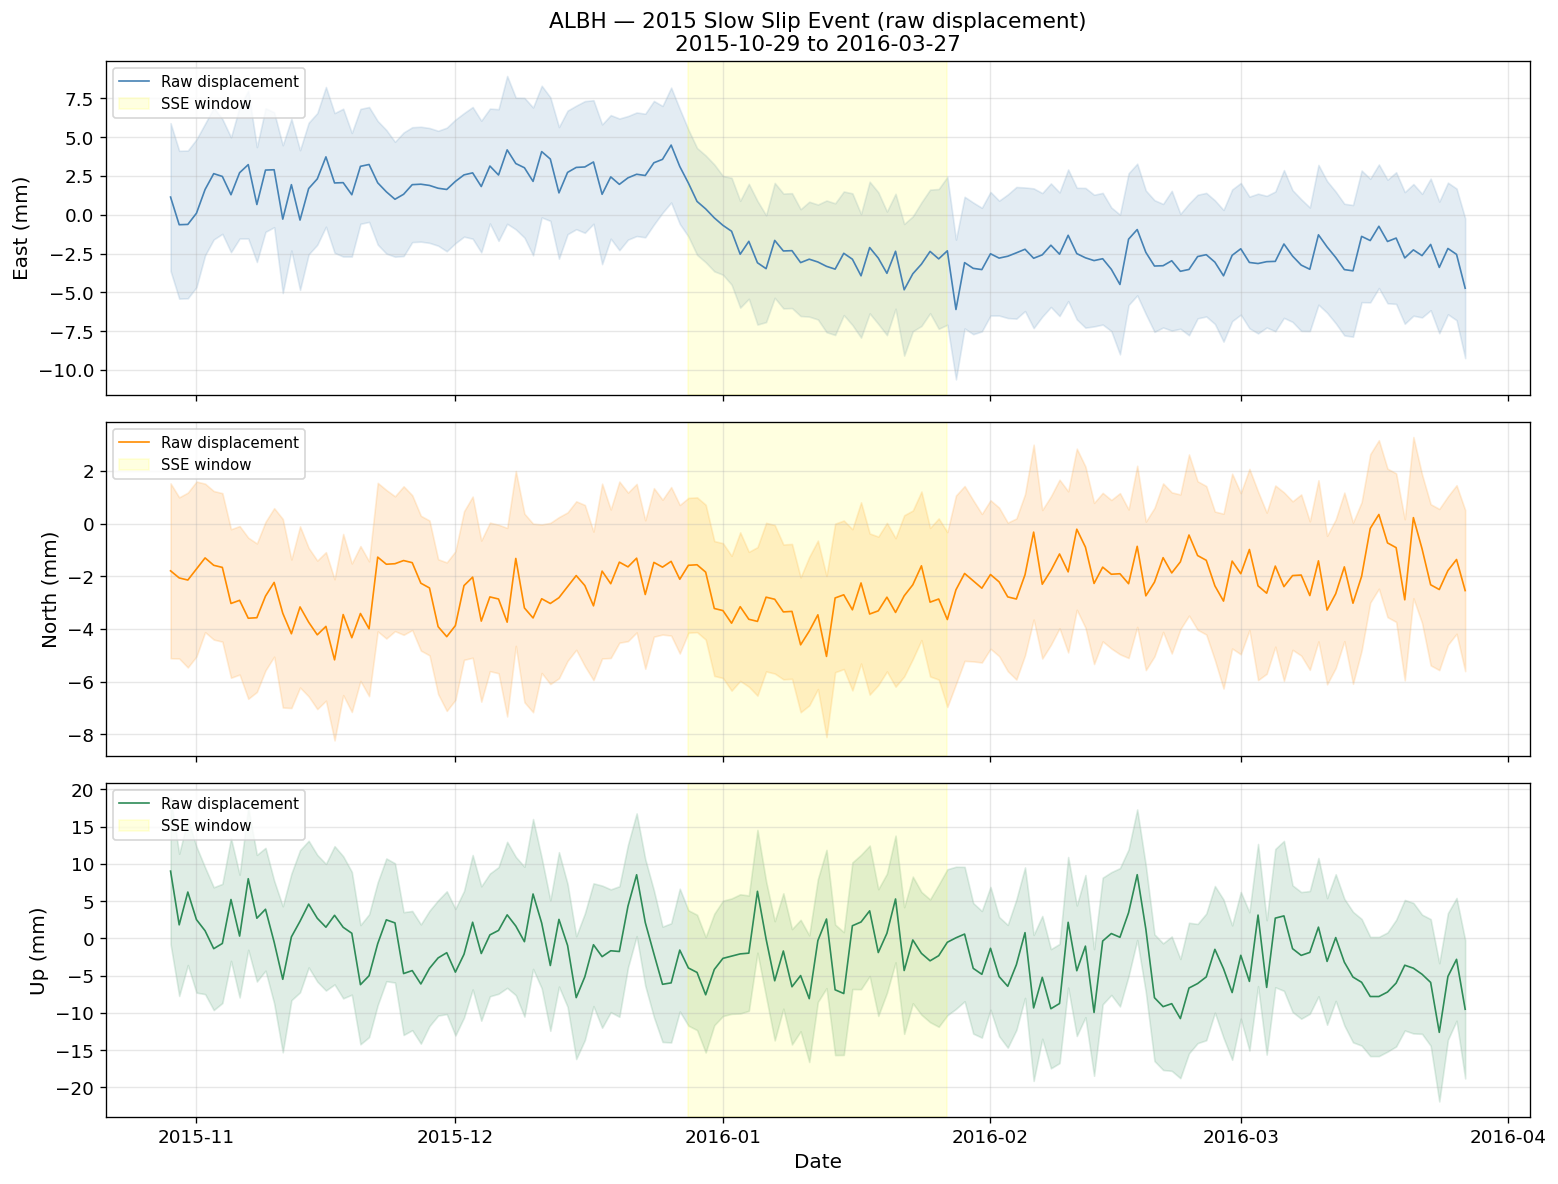

In [16]:
# ── 3-component zoom on the SSE ──────────────────────────────────────────
# Plots the RAW displacement directly (no model fit / detrending applied)
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

comp_info = [
    ('east_mm',  'East',  'steelblue'),
    ('north_mm', 'North', 'darkorange'),
    ('up_mm',    'Up',    'seagreen'),
]

for ax, (comp, label, color) in zip(axes, comp_info):
    sig_col = comp.replace('_mm', '_sig')

    sig   = df_albh.loc[mask_window, comp].values
    t_win = df_albh.loc[mask_window, 'time'].values

    ax.plot(t_win, sig, color=color, lw=1.0, label='Raw displacement')
    ax.fill_between(t_win, sig - 2*df_albh.loc[mask_window, sig_col].values,
                    sig + 2*df_albh.loc[mask_window, sig_col].values,
                    alpha=0.15, color=color)

    # Shade event period
    ax.axvspan(np.datetime64(SSE_TSTART), np.datetime64(SSE_TEND),
               alpha=0.12, color='yellow', label='SSE window')

    ax.set_ylabel(f"{label} (mm)")
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title("ALBH — 2015 Slow Slip Event (raw displacement)\n"
                   + str(t_pre_start.date()) + " to " + str(t_post_end.date()))
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 15d. Network-Wide SSE Vector Offsets and Map

For the 2015 slow slip event, we estimate **3-component (East, North, Up) offsets at all available stations** using the step-function weighted least-squares method. The horizontal vectors are plotted as displacement arrows, providing a synoptic view of the slow slip spatial footprint. This pattern can be used to constrain slip distribution on the subduction interface.

In [17]:
# ══════════════════════════════════════════════════════════════════
# NETWORK-WIDE SSE OFFSET ESTIMATION — stations within 150 km of ALBH
# Offset = mean(raw displacement, POST window) − mean(raw displacement, PRE window)
# Uses the RAW time series directly — no model fit / detrending required.
# ══════════════════════════════════════════════════════════════════

ALBH_LAT = float(ds.sel(station='albh').lat)
ALBH_LON = float(ds.sel(station='albh').lon)
MAX_DIST_KM    = 150     # only process stations within this radius of ALBH
MIN_VALID_SSE  = 10      # minimum valid observations required in EACH window
OFFSET_THRESH  = 20.0    # mm — discard any component offset larger than this
                          # (flags stations with data gaps or outliers
                          # straddling the SSE epoch)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def pre_post_offset(time_i, values_mm, t_start, t_end, pre_days, post_days):
    """Simple step estimate: mean(post-event window) - mean(pre-event window),
    computed directly on the raw time series (no model fit)."""
    t_pre_start = t_start - pd.Timedelta(days=pre_days)
    t_post_end  = t_end   + pd.Timedelta(days=post_days)

    pre_mask  = (time_i >= t_pre_start) & (time_i < t_start)
    post_mask = (time_i > t_end)        & (time_i <= t_post_end)

    pre_vals  = values_mm[pre_mask]
    post_vals = values_mm[post_mask]
    pre_vals  = pre_vals[~np.isnan(pre_vals)]
    post_vals = post_vals[~np.isnan(post_vals)]

    if len(pre_vals) < MIN_VALID_SSE or len(post_vals) < MIN_VALID_SSE:
        return None

    pre_mean, post_mean = pre_vals.mean(), post_vals.mean()
    pre_sem  = pre_vals.std(ddof=1)  / np.sqrt(len(pre_vals))  if len(pre_vals)  > 1 else 0.0
    post_sem = post_vals.std(ddof=1) / np.sqrt(len(post_vals)) if len(post_vals) > 1 else 0.0

    offset     = post_mean - pre_mean
    offset_unc = np.sqrt(pre_sem**2 + post_sem**2)
    return offset, offset_unc

print(f"SSE offset estimation — stations within {MAX_DIST_KM} km of ALBH")
print(f"SSE window      : {SSE_TSTART} → {SSE_TEND}")
print(f"Offset threshold: ±{OFFSET_THRESH} mm\n")

sse_offsets = {}

for sname in ds.station.values:
    stat_i = ds.sel(station=sname)
    lat_i  = float(stat_i.lat)
    lon_i  = float(stat_i.lon)

    if np.isnan(lat_i) or np.isnan(lon_i):
        continue

    dist_km = haversine_km(ALBH_LAT, ALBH_LON, lat_i, lon_i)
    if dist_km > MAX_DIST_KM:
        continue

    time_i = pd.to_datetime(stat_i.time.values)
    e_i = stat_i.east_m.values  * 1000
    n_i = stat_i.north_m.values * 1000
    u_i = stat_i.up_m.values    * 1000

    try:
        e_result = pre_post_offset(time_i, e_i, t_event_start, t_event_end, PRE_DAYS, POST_DAYS)
        n_result = pre_post_offset(time_i, n_i, t_event_start, t_event_end, PRE_DAYS, POST_DAYS)
        u_result = pre_post_offset(time_i, u_i, t_event_start, t_event_end, PRE_DAYS, POST_DAYS)

        if e_result is None or n_result is None or u_result is None:
            continue

        e_off, e_unc = e_result
        n_off, n_unc = n_result
        u_off, u_unc = u_result

        # Discard station if any component exceeds the anomaly threshold
        if any(abs(v) > OFFSET_THRESH for v in [e_off, n_off, u_off]):
            print(f"  {str(sname).upper():6s}  REJECTED — offset exceeds ±{OFFSET_THRESH} mm "
                  f"(E={e_off:+.1f} N={n_off:+.1f} U={u_off:+.1f})")
            continue

        h_mag = np.sqrt(e_off**2 + n_off**2)
        h_snr = h_mag / np.sqrt(e_unc**2 + n_unc**2) if (e_unc > 0 or n_unc > 0) else 0.0

        sse_offsets[str(sname)] = {
            'lat': lat_i, 'lon': lon_i, 'dist_km': dist_km,
            'Ve': e_off, 'Ve_sig': e_unc,
            'Vn': n_off, 'Vn_sig': n_unc,
            'Vu': u_off, 'Vu_sig': u_unc,
            'H_mag': h_mag, 'H_snr': h_snr,
        }
        print(f"  {str(sname).upper():6s}  dist={dist_km:5.1f} km  "
              f"E={e_off:+6.2f}±{e_unc:.2f}  "
              f"N={n_off:+6.2f}±{n_unc:.2f}  "
              f"U={u_off:+6.2f}±{u_unc:.2f} mm")

    except Exception as ex:
        print(f"  {str(sname).upper():6s}  FAILED: {ex}")

print(f"\nCompleted: {len(sse_offsets)} stations accepted within {MAX_DIST_KM} km of ALBH.")
sig_stations = {s: v for s, v in sse_offsets.items() if v['H_snr'] >= 2.0}
print(f"Stations with H_SNR ≥ 2.0: {len(sig_stations)}")

SSE offset estimation — stations within 150 km of ALBH
SSE window      : 2015-12-28 → 2016-01-27
Offset threshold: ±20.0 mm

  ALBH    dist=  0.0 km  E= -4.95±0.19  N= +0.86±0.17  U= -3.84±0.74 mm
  ARLI    dist=102.4 km  E= -2.79±0.19  N= +1.82±0.25  U= -6.46±0.91 mm
  BAMF    dist=130.9 km  E= -3.89±0.25  N= +1.95±0.23  U= +1.68±0.93 mm
  BELI    dist= 84.6 km  E= -3.96±0.26  N= +1.66±0.37  U= -3.63±0.93 mm
  BILS    dist=110.4 km  E= +0.46±0.71  N= +2.60±0.74  U= +3.57±1.76 mm
  BRN3    dist=103.8 km  E= -2.89±0.33  N= +3.80±0.37  U=-13.03±1.51 mm
  CHCM    dist= 67.5 km  E= -4.58±0.21  N= +0.37±0.18  U= -9.28±0.77 mm
  CHWK    dist=137.9 km  E= -0.89±0.18  N= +2.02±0.22  U= -8.12±1.18 mm
  CLRS    dist= 67.3 km  E= -4.20±0.20  N= +3.07±0.26  U= -1.66±0.82 mm
  CNCR    dist=129.2 km  E= -1.13±0.19  N= +3.04±0.32  U=-10.64±1.14 mm
  COUP    dist= 62.3 km  E= -5.23±0.18  N= -0.02±0.19  U=-12.30±0.83 mm
  CSKI    dist=146.0 km  E= -4.34±0.20  N= +1.47±0.22  U= -5.75±0.69 mm
  CUSH    d

In [18]:
# ══════════════════════════════════════════════════════════════════
# WRITE SSE OFFSET TEXT FILE
# ══════════════════════════════════════════════════════════════════

sse_filename = "gnss_SSE_offsets_2015.txt"

with open(sse_filename, 'w') as f:
    f.write("# GNSS 2015 Slow Slip Event Offsets\n")
    f.write(f"# Event window  : {SSE_TSTART} → {SSE_TEND}\n")
    f.write(f"# Station radius: {MAX_DIST_KM} km of ALBH "
            f"({ALBH_LAT:.3f}°N, {ALBH_LON:.3f}°E)\n")
    f.write(f"# Offset threshold: ±{OFFSET_THRESH} mm (anomalous stations excluded)\n")
    f.write("# Method: pre/post window mean-difference on the raw time series\n")
    f.write("# All offsets in mm; uncertainties are standard errors of the mean\n")
    f.write("#\n")
    f.write(f"# {'station':<8} {'lat':>9} {'lon':>10} {'dist_km':>9} "
            f"{'Ve':>9} {'Ve_sig':>8} "
            f"{'Vn':>9} {'Vn_sig':>8} "
            f"{'Vu':>9} {'Vu_sig':>8} "
            f"{'H_mag':>8} {'H_snr':>7}\n")
    f.write("# " + "-"*105 + "\n")

    for sname, v in sorted(sse_offsets.items(), key=lambda x: x[1]['dist_km']):
        f.write(f"  {sname:<8} {v['lat']:9.4f} {v['lon']:10.4f} {v['dist_km']:9.1f} "
                f"{v['Ve']:+9.4f} {v['Ve_sig']:8.4f} "
                f"{v['Vn']:+9.4f} {v['Vn_sig']:8.4f} "
                f"{v['Vu']:+9.4f} {v['Vu_sig']:8.4f} "
                f"{v['H_mag']:8.4f} {v['H_snr']:7.2f}\n")

print(f"Wrote {len(sse_offsets)} station offsets to '{sse_filename}'")
print(f"(sorted by distance from ALBH)")

Wrote 61 station offsets to 'gnss_SSE_offsets_2015.txt'
(sorted by distance from ALBH)


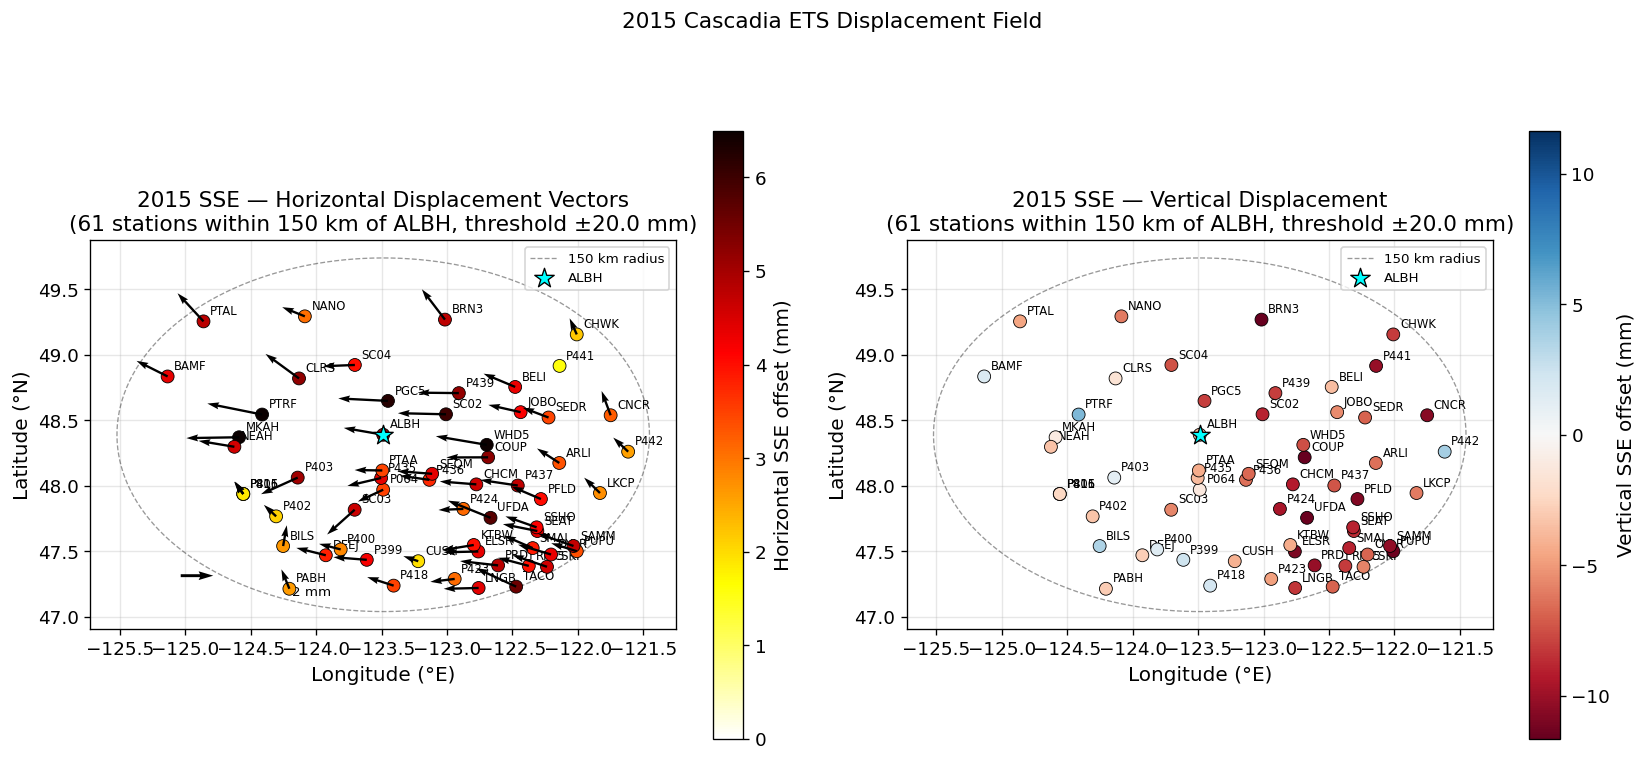

In [19]:
# ══════════════════════════════════════════════════════════════════
# SSE VECTOR MAP — stations within 150 km of ALBH
# ══════════════════════════════════════════════════════════════════

s_lats  = np.array([v['lat']    for v in sse_offsets.values()])
s_lons  = np.array([v['lon']    for v in sse_offsets.values()])
s_ve    = np.array([v['Ve']     for v in sse_offsets.values()])
s_vn    = np.array([v['Vn']     for v in sse_offsets.values()])
s_vu    = np.array([v['Vu']     for v in sse_offsets.values()])
s_hmag  = np.array([v['H_mag']  for v in sse_offsets.values()])
s_hsnr  = np.array([v['H_snr']  for v in sse_offsets.values()])
s_names = list(sse_offsets.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (vals, cmap, clabel, title) in zip(axes, [
    (s_hmag, 'hot_r',  'Horizontal SSE offset (mm)', 'Horizontal Displacement Vectors'),
    (s_vu,   'RdBu',   'Vertical SSE offset (mm)',   'Vertical Displacement'),
]):
    vmax = np.percentile(np.abs(vals), 97) if len(vals) > 0 else 1.0
    vmin = -vmax if cmap == 'RdBu' else 0

    sc = ax.scatter(s_lons, s_lats, c=vals, cmap=cmap,
                    vmin=vmin, vmax=vmax,
                    s=60, edgecolors='k', linewidths=0.5, zorder=4)
    fig.colorbar(sc, ax=ax, shrink=0.8).set_label(clabel)

    # Draw a circle showing the 150 km search radius around ALBH
    theta = np.linspace(0, 2*np.pi, 360)
    dlat  = (MAX_DIST_KM / 111.0)
    dlon  = (MAX_DIST_KM / (111.0 * np.cos(np.radians(ALBH_LAT))))
    ax.plot(ALBH_LON + dlon*np.cos(theta),
            ALBH_LAT + dlat*np.sin(theta),
            'k--', lw=0.8, alpha=0.4, label=f'{MAX_DIST_KM} km radius')

    # Station labels
    for sname, lon_s, lat_s in zip(s_names, s_lons, s_lats):
        ax.annotate(sname.upper(), (lon_s, lat_s),
                    xytext=(4, 4), textcoords='offset points', fontsize=7)

    # Horizontal vectors on left panel only
    if cmap == 'hot_r':
        mask_sig = s_hsnr >= 1.5
        if mask_sig.sum() > 0:
            ax.quiver(s_lons[mask_sig], s_lats[mask_sig],
                      s_ve[mask_sig], s_vn[mask_sig],
                      scale=None, scale_units='xy', angles='xy',
                      width=0.004, color='k', zorder=5)
        # Reference arrow
        ref_lon = s_lons.min() + 0.1
        ref_lat = s_lats.min() + 0.1
        ax.quiver(ref_lon, ref_lat, 2, 0,
                  scale=None, scale_units='xy', angles='xy',
                  width=0.005, color='k', zorder=6)
        ax.text(ref_lon + 1.0, ref_lat - 0.15, '2 mm', fontsize=8, ha='center')

    # Mark ALBH
    ax.scatter(ALBH_LON, ALBH_LAT, s=150, c='cyan', marker='*',
               edgecolors='k', linewidths=0.8, zorder=7, label='ALBH')

    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.set_title(f"2015 SSE — {title}\n"
                 f"({len(sse_offsets)} stations within {MAX_DIST_KM} km of ALBH, "
                 f"threshold ±{OFFSET_THRESH} mm)")
    ax.set_aspect('equal', adjustable='box')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("2015 Cascadia ETS Displacement Field", fontsize=13)
plt.tight_layout()
plt.show()

## 16. Tremor Catalog

If your algorithm requires the tremor catalog to help with detections, we have also provided the tremor catalog on Zenodo as a csv file. To load this into Pandas, use the code below.

In [20]:
TREMOR_URL = "https://zenodo.org/records/20276956/files/tremor_events-2010-2025.csv?download=1"
tremor = pd.read_csv(TREMOR_URL, parse_dates=["starttime"])
tremor



,lat,lon,depth,starttime,energy,duration
0,41.100714,-122.717586,20.000000,2017-11-01 21:40:00,33400.346907,300.0
1,41.098432,-122.996891,20.000000,2017-11-01 22:02:30,85501.064423,300.0
2,40.893875,-123.103896,20.000000,2017-11-01 22:17:30,48770.872090,300.0
3,40.948136,-123.123153,44.615385,2017-11-01 22:30:00,40992.256257,300.0
4,41.029690,-122.510571,58.620690,2017-11-01 07:55:00,16823.858153,300.0
...,...,...,...,...,...,...
728563,41.001208,-122.719121,20.000000,2017-11-01 20:20:00,60853.080887,300.0
728564,41.112945,-122.660070,20.000000,2017-11-01 20:40:00,160835.761644,300.0
728565,40.930355,-122.942973,33.076923,2017-11-01 20:42:30,115233.767856,300.0
728566,41.067856,-122.913335,20.000000,2017-11-01 20:45:00,15553.487850,150.0


Next we will plot the tremor per day and extract specific variables.

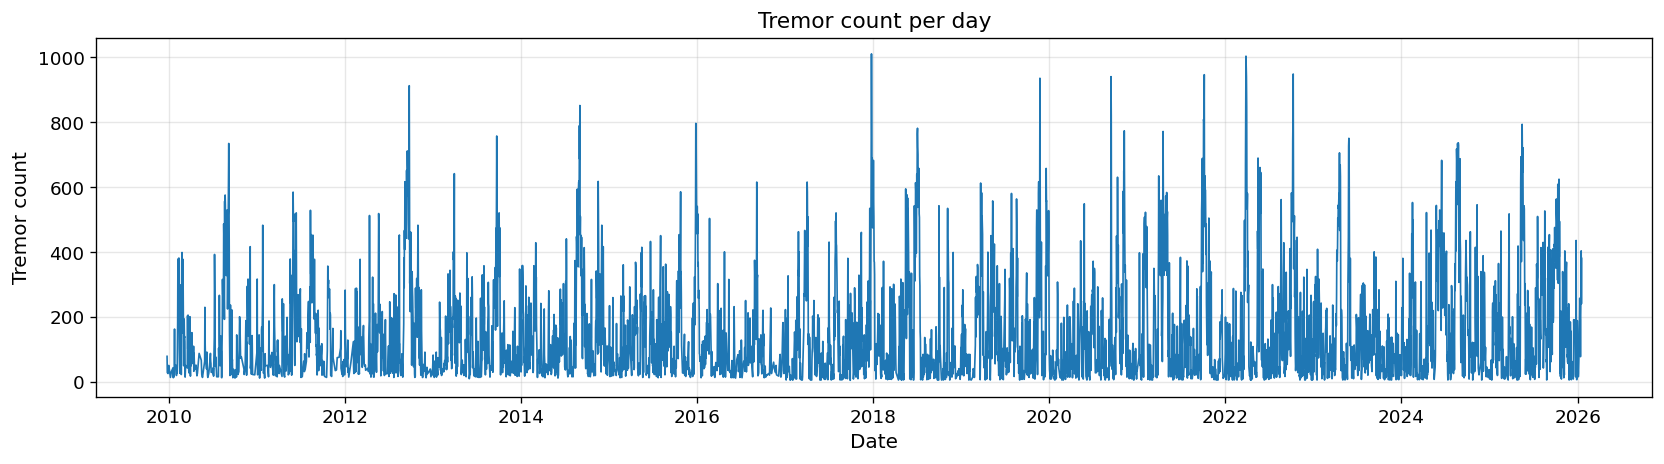

In [21]:


daily_tremor_counts = (
    tremor
    .assign(date=tremor["starttime"].dt.normalize())
    .groupby("date")
    .size()
    .rename("count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(daily_tremor_counts["date"], daily_tremor_counts["count"], linewidth=1)

ax.set_title("Tremor count per day")
ax.set_xlabel("Date")
ax.set_ylabel("Tremor count")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We can extract tremor between specific start and stop times

In [22]:


start = pd.Timestamp("2017-03-01")
end = pd.Timestamp("2017-04-01")

tremor_mar2017 = tremor[
    (tremor["starttime"] >= start) &
    (tremor["starttime"] < end)
].copy()

print(f"Selected tremor detections: {len(tremor_mar2017):,}")
print(tremor_mar2017["starttime"].min(), "to", tremor_mar2017["starttime"].max())



Selected tremor detections: 5,302
2017-03-01 00:02:30 to 2017-03-31 23:55:00


Taking the selected tremor, we plot this and color code it by date

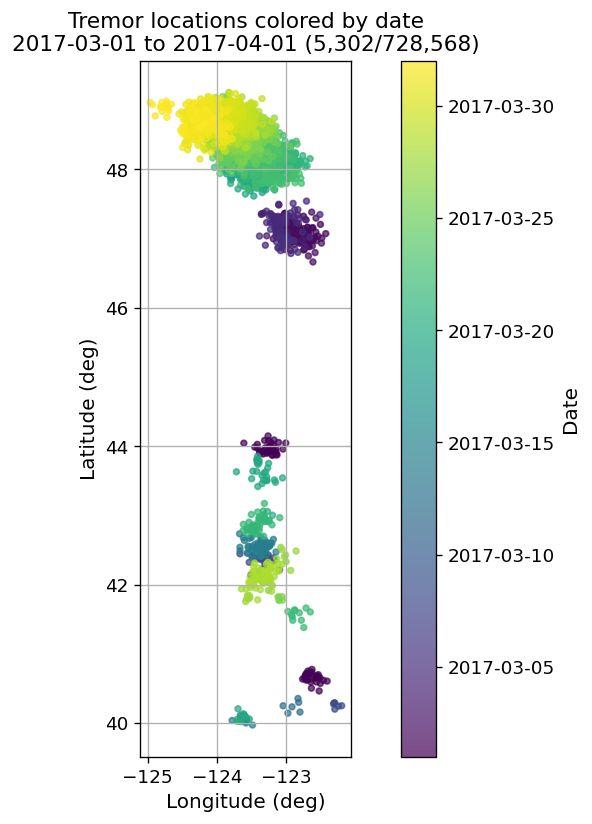

In [23]:
# Convert dates to matplotlib numeric dates for color mapping
tremor_mar2017["date_num"] = mdates.date2num(tremor_mar2017["starttime"])

n_total = len(tremor)
n_ok = len(tremor_mar2017)

plt.figure(figsize=(9, 7))

sc = plt.scatter(
    tremor_mar2017["lon"],
    tremor_mar2017["lat"],
    c=tremor_mar2017["date_num"],
    s=12,
    alpha=0.7,
)

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(
    f"Tremor locations colored by date\n"
    f"{start:%Y-%m-%d} to {end:%Y-%m-%d} ({n_ok:,}/{n_total:,})"
)
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

cbar = plt.colorbar(sc)
cbar.set_label("Date")

# Format colorbar as dates
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.tight_layout()
plt.show()


---
## References

- Crowell, B. W., et al. (2016). *Single-station automated detection of transient deformation in GPS time series with the relative strength index: A case study of Cascadian slow slip*. JGR Solid Earth. https://doi.org/10.1002/2016JB013542
- Dragert, H., Wang, K., & James, T. S. (2001). *A silent slip event on the deeper Cascadia subduction interface*. Science.
- Bock, Y., & Melgar, D. (2016). *Physical applications of GPS geodesy: a review*. Reports on Progress in Physics.
- CRESCENT Dataset: Bachelot, L. & Crowell, B. (2025). CRESCENT GNSS Time Series, Zenodo. https://zenodo.org/records/19616474